## Temperature North - South Sample
Class sampling of Northern and Southern Cities to test hypothesis that it is always warmer in South

<img src='thermometers.svg' alt='Thermometer' style="width:300px">

[Survey](https://bit.ly/EDS_Weather)

<img src=bit.ly_EDS_Weather.png style="width:300px" >

In [4]:
import numpy as np
from datascience import *
import time

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [6]:
# Google Sheet
# https://docs.google.com/spreadsheets/d/14NEf4YBmYQHHbntJ-uqksYGG3_pUfxOXNiY7D5WQuPY/edit?resourcekey=&gid=552963271#gid=552963271
sheet_id = "14NEf4YBmYQHHbntJ-uqksYGG3_pUfxOXNiY7D5WQuPY"
gid = "552963271"  # The specific sheet tab
csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

In [7]:
temps = Table.read_table(csv_url)
temps

Timestamp,Email Address,First name,Northern or Southern City?,Selected City,Current Temperature,Score,Shuffle North or South (same until switch on odd die roll)
11/1/2025 11:01:10,nan,Bob,South,Savannah,54,nan,South
11/1/2025 11:01:13,nan,Kirste,South,Charlotte,54,nan,South
11/1/2025 11:01:34,nan,Michael,North,"Scranton, PA",49,nan,North
11/1/2025 11:01:35,nan,Matthew,North,"Rome, NY",45,nan,North
11/1/2025 11:01:53,nan,Kiera,South,Atlanta,53,nan,South
11/1/2025 11:01:59,nan,Danica,South,Orlando,66,nan,South
11/1/2025 11:02:22,nan,Bob,North,Providence RI,53,nan,North
11/1/2025 11:02:30,nan,Lexi,North,New York city,53,nan,North
11/1/2025 11:02:43,nan,Sylvie,North,"Sunderland, England",52,nan,North


In [8]:
N_S_table = temps.group('Northern or Southern City?',np.mean).select(['Northern or Southern City?','Current Temperature mean'])
N_S_table

Northern or Southern City?,Current Temperature mean
North,50.4
South,56.75


In [9]:
t_stat_diffmeans = N_S_table['Current Temperature mean'].take(1) - N_S_table['Current Temperature mean'].take(0)
t_stat_diffmeans

6.3500000000000014

In [10]:
shuffle_table = temps.with_column('N or S Random', np.random.choice(['N','S'],temps.num_rows))
shuffle_table

Timestamp,Email Address,First name,Northern or Southern City?,Selected City,Current Temperature,Score,Shuffle North or South (same until switch on odd die roll),N or S Random
11/1/2025 11:01:10,nan,Bob,South,Savannah,54,nan,South,N
11/1/2025 11:01:13,nan,Kirste,South,Charlotte,54,nan,South,N
11/1/2025 11:01:34,nan,Michael,North,"Scranton, PA",49,nan,North,S
11/1/2025 11:01:35,nan,Matthew,North,"Rome, NY",45,nan,North,N
11/1/2025 11:01:53,nan,Kiera,South,Atlanta,53,nan,South,S
11/1/2025 11:01:59,nan,Danica,South,Orlando,66,nan,South,S
11/1/2025 11:02:22,nan,Bob,North,Providence RI,53,nan,North,N
11/1/2025 11:02:30,nan,Lexi,North,New York city,53,nan,North,S
11/1/2025 11:02:43,nan,Sylvie,North,"Sunderland, England",52,nan,North,S


In [11]:
sim_table = shuffle_table.group('N or S Random', np.mean).select(['N or S Random','Current Temperature mean'])
sim_table

N or S Random,Current Temperature mean
N,51.5
S,54.6


In [12]:
sim_diffmeans = sim_table['Current Temperature mean'].take(1) - sim_table['Current Temperature mean'].take(0)
sim_diffmeans

3.1000000000000014

In [ ]:
temperature = temps['Current Temperature']	

In [20]:
sample = []
original_labels = temps['Northern or Southern City?']   # 'North' / 'South' strings

for i in np.arange(1000):
    shuffled_labels = np.random.permutation(original_labels)   # shuffle, don't redraw
    shuffle_table = temps.with_column('N or S Random', shuffled_labels)
    sim_table = shuffle_table.group('N or S Random', np.mean).select(['N or S Random', 'Current Temperature mean'])
    # South (index 1) − North (index 0) — both groups always present
    sim_diffmeans = sim_table['Current Temperature mean'].item(1)- sim_table['Current Temperature mean'].item(0)
    sample.append(sim_diffmeans)

In [21]:
sim_table

N or S Random,Current Temperature mean
North,53.2
South,53.25


In [ ]:
sample

(-10.0, 10.0)

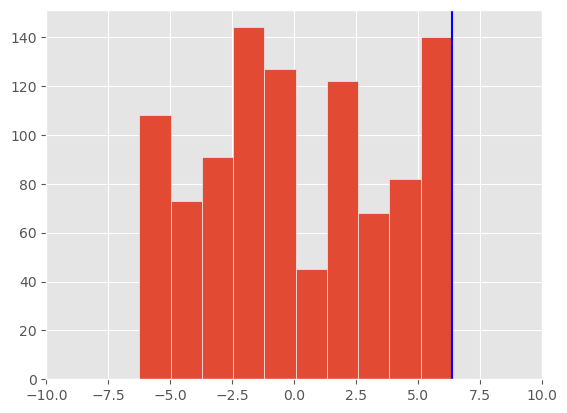

In [26]:
plt.hist(sample)
plt.axvline(t_stat_diffmeans, color='blue')
plt.xlim(-10,10)

In [25]:
p_value = np.count_nonzero(sample >= t_stat_diffmeans)/len(sample)
p_value

0.026